# 15. 유지보수 계획: 시스템 아키텍처 문서화 · 모니터링 계획 수립

## 학습 목표
1. PCB AOI 시각 AI 시스템의 **아키텍처를 문서화**한다.
2. 운영 **모니터링 지표·알람·SLA**를 정의한다.
3. 유지보수 **일정·책임·장애 대응 절차**를 수립한다.

---

## 문서 산출물

| 산출물 | 설명 |
|--------|------|
| `architecture_doc.json` | 컴포넌트·데이터 흐름·의존성 |
| `monitoring_plan.json` | 메트릭·임계값·알람 규칙 |
| `maintenance_calendar.csv` | 정기 점검 일정 |
| `runbook_incident.md` | 장애 대응 절차 |

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
OUT_DIR = PROJECT_ROOT / "outputs" / "maintenance"
DOCS_DIR = PROJECT_ROOT / "docs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)
print("DOCS_DIR:", DOCS_DIR)

PROJECT_ROOT: C:\MyCursorLab\10_프로젝트
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\maintenance
DOCS_DIR: C:\MyCursorLab\10_프로젝트\docs


## 1) 시스템 아키텍처 문서화

### 1-1. 계층 구조 (C4 스타일 요약)

```text
┌─────────────────────────────────────────────────────────────┐
│  Presentation: Streamlit / FastAPI / 운영 대시보드            │
├─────────────────────────────────────────────────────────────┤
│  Application: VisualAIWebService, LLMInferenceService       │
├─────────────────────────────────────────────────────────────┤
│  Domain: VisionModule, SensorModule, FusionService          │
├─────────────────────────────────────────────────────────────┤
│  Data: PCB 이미지(YOLO), 센서 CSV, 피드백/설정 JSON            │
├─────────────────────────────────────────────────────────────┤
│  Infra: Edge GPU, AOI 라인, MES 연동(확장)                    │
└─────────────────────────────────────────────────────────────┘
```

### 1-2. 데이터 흐름

`이미지+센서` → 전처리 → Feature/추론 → Fusion → LLM 해석 → API 응답 → 피드백 저장

In [2]:
ARCHITECTURE_DOC = {
    "system_name": "PCB AOI Visual AI Platform",
    "version": "1.0.0",
    "documented_at": datetime.now().isoformat(timespec="seconds"),
    "layers": [
        {
            "layer": "presentation",
            "components": [
                {"id": "api_gateway", "name": "FastAPI", "endpoints": ["/health", "/analyze", "/feedback"]},
                {"id": "dashboard", "name": "Streamlit Dashboard", "note": "선택 구현"},
            ],
        },
        {
            "layer": "application",
            "components": [
                {"id": "web_service", "name": "VisualAIWebService", "notebook": "13"},
                {"id": "llm_service", "name": "LLMInferenceService", "notebook": "12"},
                {"id": "eval_service", "name": "mAP Evaluation", "notebook": "08-10"},
            ],
        },
        {
            "layer": "domain",
            "components": [
                {"id": "vision", "name": "VisionModule", "input": "grayscale image", "output": "vision_risk_score"},
                {"id": "sensor", "name": "SensorModule", "input": "lux/temp/vibration", "output": "sensor_risk_score"},
                {"id": "fusion", "name": "FusionService", "output": "fused_risk_score, risk_level"},
                {"id": "pipeline", "name": "IndustrialPipeline", "notebook": "14"},
            ],
        },
        {
            "layer": "data",
            "artifacts": [
                "data/pcb-defect-dataset/",
                "outputs/core_modules/fusion_result.json",
                "outputs/system_integration/service_config.json",
                "outputs/maintenance/",
            ],
        },
    ],
    "dependencies": [
        {"from": "web_service", "to": "vision", "type": "sync_call"},
        {"from": "web_service", "to": "sensor", "type": "sync_call"},
        {"from": "web_service", "to": "fusion", "type": "sync_call"},
        {"from": "web_service", "to": "llm_service", "type": "sync_call"},
        {"from": "fusion", "to": "service_config", "type": "config_read"},
        {"from": "feedback", "to": "service_config", "type": "config_write"},
    ],
    "notebooks_map": {
        "01-03": "문제정의·EDA·멀티모달",
        "04-05": "Feature·img2col",
        "06-07": "전처리·시각데이터",
        "08-10": "객체검출 평가",
        "11-13": "통합·웹·LLM",
        "14": "서비스 고도화",
        "15": "유지보수·모니터링",
    },
}

with open(DOCS_DIR / "architecture_doc.json", "w", encoding="utf-8") as f:
    json.dump(ARCHITECTURE_DOC, f, ensure_ascii=False, indent=2)

# 컴포넌트 인벤토리 테이블
comp_rows = []
for layer in ARCHITECTURE_DOC["layers"]:
    for c in layer.get("components", []):
        comp_rows.append({
            "layer": layer["layer"],
            "id": c.get("id", c.get("name", "")),
            "name": c.get("name", ""),
            "notebook": c.get("notebook", ""),
        })
comp_df = pd.DataFrame(comp_rows)
display(comp_df)
print("저장:", DOCS_DIR / "architecture_doc.json")

,layer,id,name,notebook
0,presentation,api_gateway,FastAPI,
1,presentation,dashboard,Streamlit Dashboard,
2,application,web_service,VisualAIWebService,13
3,application,llm_service,LLMInferenceService,12
4,application,eval_service,mAP Evaluation,08-10
5,domain,vision,VisionModule,
6,domain,sensor,SensorModule,
7,domain,fusion,FusionService,
8,domain,pipeline,IndustrialPipeline,14


저장: C:\MyCursorLab\10_프로젝트\docs\architecture_doc.json


## 2) 모니터링 계획 수립

### 2-1. 모니터링 4대 황금 신호 (Google SRE 관점)

| 영역 | 메트릭 | 목적 |
|------|--------|------|
| **Latency** | p95 `/analyze` ms | 사용자 체감 속도 |
| **Traffic** | requests/min | 부하 추세 |
| **Errors** | 5xx, validation_fail | 안정성 |
| **Saturation** | GPU/CPU %, queue depth | 용량 계획 |

### 2-2. 도메인 KPI (품질)

| 메트릭 | 설명 | 목표 |
|--------|------|------|
| `mAP@0.5` | 검출 성능 | ≥ baseline - 2% |
| `feedback_accuracy` | 운영자 일치율 | ≥ 85% |
| `human_review_rate` | LLM 저신뢰 비율 | ≤ 15% |
| `quality_gate_block_rate` | 불량 입력 차단 | 모니터링 |

In [3]:
MONITORING_PLAN = {
    "plan_version": "1.0",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "sla": {
        "availability_monthly": 0.995,
        "analyze_p95_ms": 500,
        "health_check_interval_sec": 30,
    },
    "metrics": [
        {"id": "api_latency_p95", "type": "histogram", "unit": "ms", "warn": 400, "critical": 800, "source": "/analyze"},
        {"id": "api_error_rate", "type": "gauge", "unit": "ratio", "warn": 0.01, "critical": 0.05, "source": "gateway"},
        {"id": "requests_per_min", "type": "counter", "unit": "rpm", "warn": None, "critical": None, "source": "gateway"},
        {"id": "gpu_utilization", "type": "gauge", "unit": "percent", "warn": 85, "critical": 95, "source": "node_exporter"},
        {"id": "fusion_high_risk_rate", "type": "gauge", "unit": "ratio", "warn": 0.25, "critical": 0.40, "source": "app"},
        {"id": "llm_human_review_rate", "type": "gauge", "unit": "ratio", "warn": 0.20, "critical": 0.35, "source": "llm"},
        {"id": "feedback_accuracy_7d", "type": "gauge", "unit": "ratio", "warn": 0.80, "critical": 0.70, "source": "feedback_store"},
        {"id": "pipeline_quality_gate_fail", "type": "counter", "unit": "count", "warn": 50, "critical": 200, "source": "pipeline", "window": "1h"},
        {"id": "model_map50_weekly", "type": "gauge", "unit": "score", "warn_drop": 0.02, "critical_drop": 0.05, "source": "eval_job"},
    ],
    "alerts": [
        {"name": "HighLatency", "metric": "api_latency_p95", "condition": "> critical", "channel": ["slack", "email"], "severity": "P2"},
        {"name": "HighErrorRate", "metric": "api_error_rate", "condition": "> critical", "channel": ["slack", "pager"], "severity": "P1"},
        {"name": "GPUSaturation", "metric": "gpu_utilization", "condition": "> critical", "channel": ["slack"], "severity": "P2"},
        {"name": "ModelDrift", "metric": "model_map50_weekly", "condition": "drop > critical_drop", "channel": ["email"], "severity": "P3"},
        {"name": "LowFeedbackAccuracy", "metric": "feedback_accuracy_7d", "condition": "< critical", "channel": ["slack"], "severity": "P2"},
    ],
    "dashboards": [
        {"name": "Operations Overview", "panels": ["requests_per_min", "api_latency_p95", "api_error_rate"]},
        {"name": "Quality", "panels": ["fusion_high_risk_rate", "feedback_accuracy_7d", "model_map50_weekly"]},
        {"name": "Infrastructure", "panels": ["gpu_utilization", "pipeline_quality_gate_fail"]},
    ],
    "log_retention_days": 30,
    "metric_retention_days": 90,
}

with open(OUT_DIR / "monitoring_plan.json", "w", encoding="utf-8") as f:
    json.dump(MONITORING_PLAN, f, ensure_ascii=False, indent=2)

metrics_df = pd.DataFrame(MONITORING_PLAN["metrics"])
alerts_df = pd.DataFrame(MONITORING_PLAN["alerts"])
display(metrics_df)
display(alerts_df)
print("저장:", OUT_DIR / "monitoring_plan.json")

,id,type,unit,warn,critical,source,window,warn_drop,critical_drop
0,api_latency_p95,histogram,ms,400.00,800.00,/analyze,NaN,NaN,NaN
1,api_error_rate,gauge,ratio,0.01,0.05,gateway,NaN,NaN,NaN
2,requests_per_min,counter,rpm,NaN,NaN,gateway,NaN,NaN,NaN
3,gpu_utilization,gauge,percent,85.00,95.00,node_exporter,NaN,NaN,NaN
4,fusion_high_risk_rate,gauge,ratio,0.25,0.40,app,NaN,NaN,NaN
5,llm_human_review_rate,gauge,ratio,0.20,0.35,llm,NaN,NaN,NaN
6,feedback_accuracy_7d,gauge,ratio,0.80,0.70,feedback_store,NaN,NaN,NaN
7,pipeline_quality_gate_fail,counter,count,50.00,200.00,pipeline,1h,NaN,NaN
8,model_map50_weekly,gauge,score,NaN,NaN,eval_job,NaN,0.02,0.05


,name,metric,condition,channel,severity
0,HighLatency,api_latency_p95,> critical,"[slack, email]",P2
1,HighErrorRate,api_error_rate,> critical,"[slack, pager]",P1
2,GPUSaturation,gpu_utilization,> critical,[slack],P2
3,ModelDrift,model_map50_weekly,drop > critical_drop,[email],P3
4,LowFeedbackAccuracy,feedback_accuracy_7d,< critical,[slack],P2


저장: C:\MyCursorLab\10_프로젝트\outputs\maintenance\monitoring_plan.json


## 3) 모니터링 시뮬레이션 (샘플 메트릭 생성)

실제 Prometheus/Grafana 연동 전, 임계값 설계를 검증합니다.

In [4]:
rng = np.random.default_rng(2026)
hours = 24 * 7  # 1주
t = pd.date_range(end=datetime.now(), periods=hours, freq="h")

sim = pd.DataFrame({
    "timestamp": t,
    "api_latency_p95": 180 + rng.normal(0, 40, hours) + 50 * (rng.random(hours) > 0.95),
    "api_error_rate": np.clip(rng.exponential(0.005, hours), 0, 0.1),
    "requests_per_min": 30 + 15 * np.sin(2 * np.pi * np.arange(hours) / 24) + rng.normal(0, 5, hours),
    "gpu_utilization": np.clip(55 + rng.normal(0, 12, hours), 0, 100),
    "feedback_accuracy_7d": np.clip(0.88 + rng.normal(0, 0.03, hours), 0.6, 1.0),
    "llm_human_review_rate": np.clip(0.12 + rng.normal(0, 0.04, hours), 0, 0.5),
})

# 알람 규칙 적용
def check_alerts(row: pd.Series) -> list[str]:
    fired = []
    if row["api_latency_p95"] > 800:
        fired.append("HighLatency")
    if row["api_error_rate"] > 0.05:
        fired.append("HighErrorRate")
    if row["gpu_utilization"] > 95:
        fired.append("GPUSaturation")
    if row["feedback_accuracy_7d"] < 0.70:
        fired.append("LowFeedbackAccuracy")
    return fired

sim["alerts"] = sim.apply(check_alerts, axis=1)
sim["alert_count"] = sim["alerts"].apply(len)

print("1주 시뮬레이션 알람 발생 횟수:")
for name in ["HighLatency", "HighErrorRate", "GPUSaturation", "LowFeedbackAccuracy"]:
  cnt = sim["alerts"].apply(lambda xs: name in xs).sum()
  print(f"  {name}: {cnt}회")

sim.to_csv(OUT_DIR / "monitoring_simulation_7d.csv", index=False, encoding="utf-8-sig")
sim.tail(3)

1주 시뮬레이션 알람 발생 횟수:
  HighLatency: 0회
  HighErrorRate: 0회
  GPUSaturation: 0회
  LowFeedbackAccuracy: 0회


,timestamp,api_latency_p95,api_error_rate,requests_per_min,gpu_utilization,feedback_accuracy_7d,llm_human_review_rate,alerts,alert_count
165,2026-07-10 13:16:17.420249,143.187281,0.001614,14.332533,55.281703,0.815153,0.134397,[],0
166,2026-07-10 14:16:17.420249,211.549543,0.002874,23.971686,59.875103,0.891581,0.071730,[],0
167,2026-07-10 15:16:17.420249,209.725105,0.013175,31.728937,52.148771,0.877447,0.127588,[],0


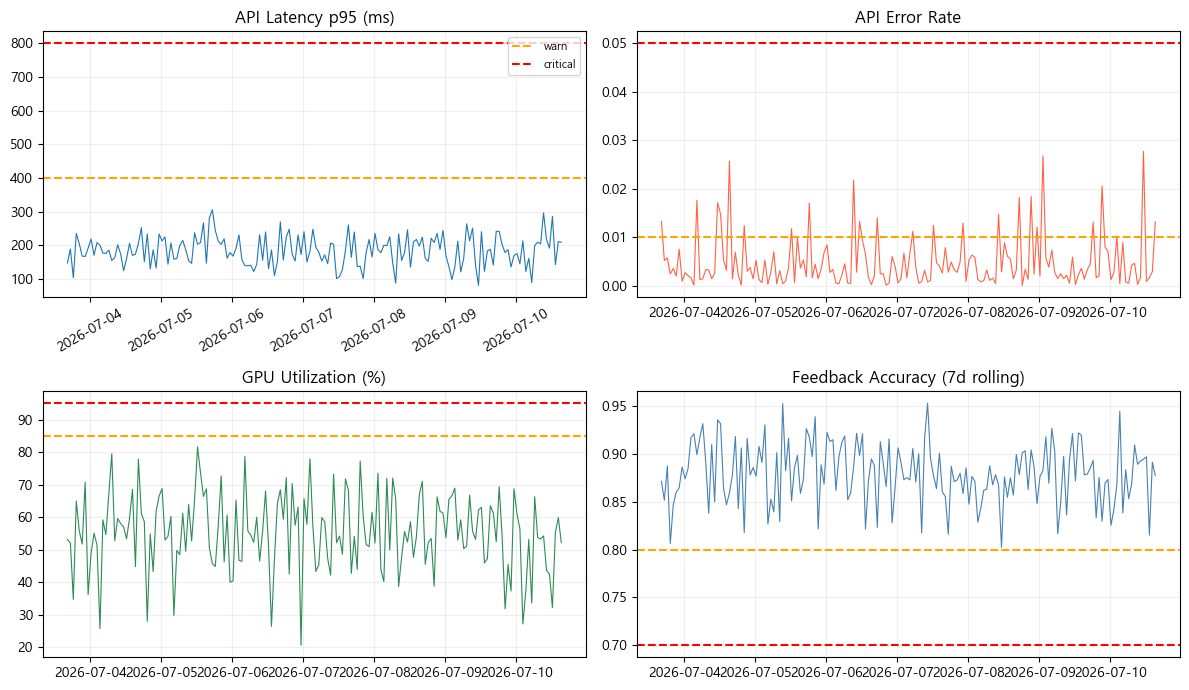

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(sim["timestamp"], sim["api_latency_p95"], linewidth=0.8)
axes[0, 0].axhline(400, color="orange", linestyle="--", label="warn")
axes[0, 0].axhline(800, color="red", linestyle="--", label="critical")
axes[0, 0].set_title("API Latency p95 (ms)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].plot(sim["timestamp"], sim["api_error_rate"], color="tomato", linewidth=0.8)
axes[0, 1].axhline(0.01, color="orange", linestyle="--")
axes[0, 1].axhline(0.05, color="red", linestyle="--")
axes[0, 1].set_title("API Error Rate")

axes[1, 0].plot(sim["timestamp"], sim["gpu_utilization"], color="seagreen", linewidth=0.8)
axes[1, 0].axhline(85, color="orange", linestyle="--")
axes[1, 0].axhline(95, color="red", linestyle="--")
axes[1, 0].set_title("GPU Utilization (%)")

axes[1, 1].plot(sim["timestamp"], sim["feedback_accuracy_7d"], color="steelblue", linewidth=0.8)
axes[1, 1].axhline(0.80, color="orange", linestyle="--")
axes[1, 1].axhline(0.70, color="red", linestyle="--")
axes[1, 1].set_title("Feedback Accuracy (7d rolling)")

for ax in axes.flatten():
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 4) 유지보수 일정 · RACI

| 주기 | 작업 | 담당 |
|------|------|------|
| 일일 | 헬스체크, 알람 확인, 로그 스캔 | 운영 |
| 주간 | mAP 샘플 평가, 피드백 리뷰 | ML 엔지니어 |
| 월간 | 모델 재학습 검토, 설정 백업 | ML + 품질 |
| 분기 | 아키텍처 문서 갱신, DR 훈련 | 아키텍트 |

In [6]:
today = datetime.now().date()

MAINTENANCE_TASKS = [
    {"task_id": "M-D01", "frequency": "daily", "task": "API /health 및 알람 대시보드 확인", "owner": "운영", "duration_min": 15},
    {"task_id": "M-D02", "frequency": "daily", "task": "품질 게이트 차단 로그 검토", "owner": "운영", "duration_min": 10},
    {"task_id": "M-W01", "frequency": "weekly", "task": "test split mAP@0.5 자동 평가 실행", "owner": "ML", "duration_min": 60},
    {"task_id": "M-W02", "frequency": "weekly", "task": "피드백 로그 분석 및 가중치 검토", "owner": "ML", "duration_min": 45},
    {"task_id": "M-W03", "frequency": "weekly", "task": "service_config.json 백업", "owner": "운영", "duration_min": 10},
    {"task_id": "M-M01", "frequency": "monthly", "task": "모델 드리프트 리포트 작성", "owner": "ML", "duration_min": 120},
    {"task_id": "M-M02", "frequency": "monthly", "task": "센서 캘리브레이션 현장 점검", "owner": "설비", "duration_min": 180},
    {"task_id": "M-M03", "frequency": "monthly", "task": "아키텍처/모니터링 문서 갱신", "owner": "아키텍트", "duration_min": 90},
    {"task_id": "M-Q01", "frequency": "quarterly", "task": "재해 복구(DR) 시뮬레이션", "owner": "인프라", "duration_min": 240},
    {"task_id": "M-Q02", "frequency": "quarterly", "task": "보안 패치 및 의존성 업데이트", "owner": "인프라", "duration_min": 180},
]

maint_df = pd.DataFrame(MAINTENANCE_TASKS)

# 향후 4주 캘린더 생성 (간단 스케줄)
calendar_rows = []
for week in range(4):
    week_start = today + timedelta(days=7 * week)
    for _, row in maint_df.iterrows():
        if row["frequency"] == "daily":
            for d in range(5):  # 월~금
                calendar_rows.append({
                    "date": str(week_start + timedelta(days=d)),
                    "task_id": row["task_id"],
                    "task": row["task"],
                    "owner": row["owner"],
                })
        elif row["frequency"] == "weekly" and week < 4:
            calendar_rows.append({
                "date": str(week_start),
                "task_id": row["task_id"],
                "task": row["task"],
                "owner": row["owner"],
            })
        elif row["frequency"] == "monthly" and week == 0:
            calendar_rows.append({
                "date": str(week_start),
                "task_id": row["task_id"],
                "task": row["task"],
                "owner": row["owner"],
            })

calendar_df = pd.DataFrame(calendar_rows).sort_values("date")
maint_df.to_csv(OUT_DIR / "maintenance_task_catalog.csv", index=False, encoding="utf-8-sig")
calendar_df.to_csv(OUT_DIR / "maintenance_calendar_4w.csv", index=False, encoding="utf-8-sig")

display(maint_df)
print(f"4주 캘린더 항목 수: {len(calendar_df)}")
display(calendar_df.head(8))

,task_id,frequency,task,owner,duration_min
0,M-D01,daily,API /health 및 알람 대시보드 확인,운영,15
1,M-D02,daily,품질 게이트 차단 로그 검토,운영,10
2,M-W01,weekly,test split mAP@0.5 자동 평가 실행,ML,60
3,M-W02,weekly,피드백 로그 분석 및 가중치 검토,ML,45
4,M-W03,weekly,service_config.json 백업,운영,10
5,M-M01,monthly,모델 드리프트 리포트 작성,ML,120
6,M-M02,monthly,센서 캘리브레이션 현장 점검,설비,180
7,M-M03,monthly,아키텍처/모니터링 문서 갱신,아키텍트,90
8,M-Q01,quarterly,재해 복구(DR) 시뮬레이션,인프라,240
9,M-Q02,quarterly,보안 패치 및 의존성 업데이트,인프라,180


4주 캘린더 항목 수: 55


,date,task_id,task,owner
0,2026-07-10,M-D01,API /health 및 알람 대시보드 확인,운영
15,2026-07-10,M-M03,아키텍처/모니터링 문서 갱신,아키텍트
5,2026-07-10,M-D02,품질 게이트 차단 로그 검토,운영
14,2026-07-10,M-M02,센서 캘리브레이션 현장 점검,설비
10,2026-07-10,M-W01,test split mAP@0.5 자동 평가 실행,ML
11,2026-07-10,M-W02,피드백 로그 분석 및 가중치 검토,ML
12,2026-07-10,M-W03,service_config.json 백업,운영
13,2026-07-10,M-M01,모델 드리프트 리포트 작성,ML


## 5) 장애 대응 Runbook (요약)

| Severity | 예시 | 1차 조치 | 에스컬레이션 |
|----------|------|----------|--------------|
| P1 | API 전면 장애 | 롤백, 헬스 복구 | 15분 내 인프라 |
| P2 | 지연 급증 | 배치 크기↓, 캐시 확인 | ML/운영 |
| P3 | mAP 하락 | eval 리포트, 재학습 검토 | ML 주간 회의 |

In [7]:
RUNBOOK = """# PCB AOI Visual AI — Incident Runbook

## P1: API Unavailable
1. `GET /health` 확인
2. 최근 배포/설정 변경 이력 확인 (`service_config.json`, `deploy_config_template.json`)
3. 이전 버전 컨테이너/프로세스로 롤백
4. 장애 타임라인 기록 (outputs/maintenance/incident_log.json)

## P2: High Latency (p95 > 800ms)
1. GPU/CPU 사용률 대시보드 확인
2. `batch_size` 축소, 캐시 hit rate 확인
3. 품질 게이트로 불필요 추론 차단 여부 확인
4. 30분 내 미해결 시 ML 엔지니어 호출

## P3: Model Quality Drop (mAP -5%)
1. `outputs/detection_eval/` 최신 리포트 비교
2. 데이터 분포 drift (조명/센서) EDA
3. 피드백 로그에서 systematic bias 확인
4. 재학습/임계값 조정 계획 수립 (주간 회의)

## 연락처 (템플릿)
- 운영 온콜: ___________
- ML 온콜: ___________
- 설비: ___________
"""

(DOCS_DIR / "runbook_incident.md").write_text(RUNBOOK, encoding="utf-8")
print("저장:", DOCS_DIR / "runbook_incident.md")
print(RUNBOOK[:500], "...")

저장: C:\MyCursorLab\10_프로젝트\docs\runbook_incident.md
# PCB AOI Visual AI — Incident Runbook

## P1: API Unavailable
1. `GET /health` 확인
2. 최근 배포/설정 변경 이력 확인 (`service_config.json`, `deploy_config_template.json`)
3. 이전 버전 컨테이너/프로세스로 롤백
4. 장애 타임라인 기록 (outputs/maintenance/incident_log.json)

## P2: High Latency (p95 > 800ms)
1. GPU/CPU 사용률 대시보드 확인
2. `batch_size` 축소, 캐시 hit rate 확인
3. 품질 게이트로 불필요 추론 차단 여부 확인
4. 30분 내 미해결 시 ML 엔지니어 호출

## P3: Model Quality Drop (mAP -5%)
1. `outputs/detection_eval/` 최신 리포트 비교
2. 데이터 분포 drift (조명/센서) EDA
3. 피드백 로그에서 sy ...


In [8]:
# 통합 유지보수 마스터 리포트
master_report = {
    "title": "PCB AOI Visual AI — Maintenance & Monitoring Master Plan",
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "architecture": {
        "doc_path": str(DOCS_DIR / "architecture_doc.json"),
        "component_count": len(comp_df),
        "layer_count": len(ARCHITECTURE_DOC["layers"]),
    },
    "monitoring": {
        "plan_path": str(OUT_DIR / "monitoring_plan.json"),
        "metric_count": len(MONITORING_PLAN["metrics"]),
        "alert_rules": len(MONITORING_PLAN["alerts"]),
        "sla_availability": MONITORING_PLAN["sla"]["availability_monthly"],
        "simulation_alert_hours": int(sim["alert_count"].sum()),
    },
    "maintenance": {
        "task_catalog": len(maint_df),
        "calendar_4w_items": len(calendar_df),
        "runbook_path": str(DOCS_DIR / "runbook_incident.md"),
    },
    "checklist_release": [
        "architecture_doc.json 최신화",
        "monitoring_plan.json Grafana 반영",
        "주간 mAP eval CI 등록",
        "피드백 백업 경로 확인",
        "runbook_incident.md 온콜 공유",
    ],
}

with open(OUT_DIR / "maintenance_master_report.json", "w", encoding="utf-8") as f:
    json.dump(master_report, f, ensure_ascii=False, indent=2)

print("=== 유지보수 마스터 리포트 ===")
print(json.dumps(master_report, indent=2, ensure_ascii=False))

print("\n생성 파일 목록:")
for p in [
    DOCS_DIR / "architecture_doc.json",
    DOCS_DIR / "runbook_incident.md",
    OUT_DIR / "monitoring_plan.json",
    OUT_DIR / "monitoring_simulation_7d.csv",
    OUT_DIR / "maintenance_task_catalog.csv",
    OUT_DIR / "maintenance_calendar_4w.csv",
    OUT_DIR / "maintenance_master_report.json",
]:
    print("-", p)

=== 유지보수 마스터 리포트 ===
{
  "title": "PCB AOI Visual AI — Maintenance & Monitoring Master Plan",
  "generated_at": "2026-07-10T15:16:17",
  "architecture": {
    "doc_path": "C:\\MyCursorLab\\10_프로젝트\\docs\\architecture_doc.json",
    "component_count": 9,
    "layer_count": 4
  },
  "monitoring": {
    "plan_path": "C:\\MyCursorLab\\10_프로젝트\\outputs\\maintenance\\monitoring_plan.json",
    "metric_count": 9,
    "alert_rules": 5,
    "sla_availability": 0.995,
    "simulation_alert_hours": 0
  },
  "maintenance": {
    "task_catalog": 10,
    "calendar_4w_items": 55,
    "runbook_path": "C:\\MyCursorLab\\10_프로젝트\\docs\\runbook_incident.md"
  },
  "checklist_release": [
    "architecture_doc.json 최신화",
    "monitoring_plan.json Grafana 반영",
    "주간 mAP eval CI 등록",
    "피드백 백업 경로 확인",
    "runbook_incident.md 온콜 공유"
  ]
}

생성 파일 목록:
- C:\MyCursorLab\10_프로젝트\docs\architecture_doc.json
- C:\MyCursorLab\10_프로젝트\docs\runbook_incident.md
- C:\MyCursorLab\10_프로젝트\outputs\maintenance\monitoring_

## 실습 과제

1. `MONITORING_PLAN`에 MES 연동 지연 메트릭을 추가하세요.
2. Grafana 대시보드 JSON 스켈레톤을 `docs/grafana_dashboard.json`으로 작성하세요.
3. RACI 표를 팀 역할에 맞게 채우고 `maintenance_raci.csv`로 저장하세요.
4. 분기 DR 훈련 체크리스트를 runbook에 추가하세요.

---

## 프로젝트 노트북 로드맵 (01~15)

| 구간 | 노트북 | 주제 |
|------|--------|------|
| 기초 | 01~03 | 문제정의·EDA·멀티모달 |
| 기술 | 04~05 | Feature·img2col |
| 데이터 | 06~07 | 전처리·시각 구성 |
| 평가 | 08~10 | mAP·자동 리포트 |
| 통합 | 11~13 | 모듈·LLM·웹·통합테스트 |
| 운영 | 14~15 | 고도화·유지보수 |

### 한 줄 정리
**문서화된 아키텍처 + 측정 가능한 모니터링 + 정기 유지보수**가 서비스 수명을 결정합니다.